In [60]:
import pandas as pd
all_data = pd.read_csv("../data/2025_minute.csv", sep=';')

In [61]:
# Ensure Datetime is the index or a column
df = all_data[["Datetime", "Imbalance Price"]].copy()
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df = df.sort_values('Datetime', ascending=True).reset_index(drop=True)

# Extract basic time features for analysis
df['Month'] = df['Datetime'].dt.month
df['DayOfWeek'] = df['Datetime'].dt.dayofweek # 0 = Monday, 6 = Sunday
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['Minute_in_Quarter'] = df['Minute'] % 15

In [62]:
df

,Datetime,Imbalance Price,Month,DayOfWeek,Hour,Minute,Minute_in_Quarter
0,2024-12-31 23:00:00+00:00,43.959,12,1,23,0,0
1,2024-12-31 23:01:00+00:00,0.050,12,1,23,1,1
2,2024-12-31 23:02:00+00:00,0.050,12,1,23,2,2
3,2024-12-31 23:03:00+00:00,0.050,12,1,23,3,3
4,2024-12-31 23:04:00+00:00,0.050,12,1,23,4,4
...,...,...,...,...,...,...,...
415968,2025-10-16 21:55:00+00:00,84.022,10,3,21,55,10
415969,2025-10-16 21:56:00+00:00,83.497,10,3,21,56,11
415970,2025-10-16 21:57:00+00:00,82.560,10,3,21,57,12
415971,2025-10-16 21:58:00+00:00,81.269,10,3,21,58,13


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
# Setup plotting style
plt.style.use('seaborn-v0_8-whitegrid')

### Testing the correlation between


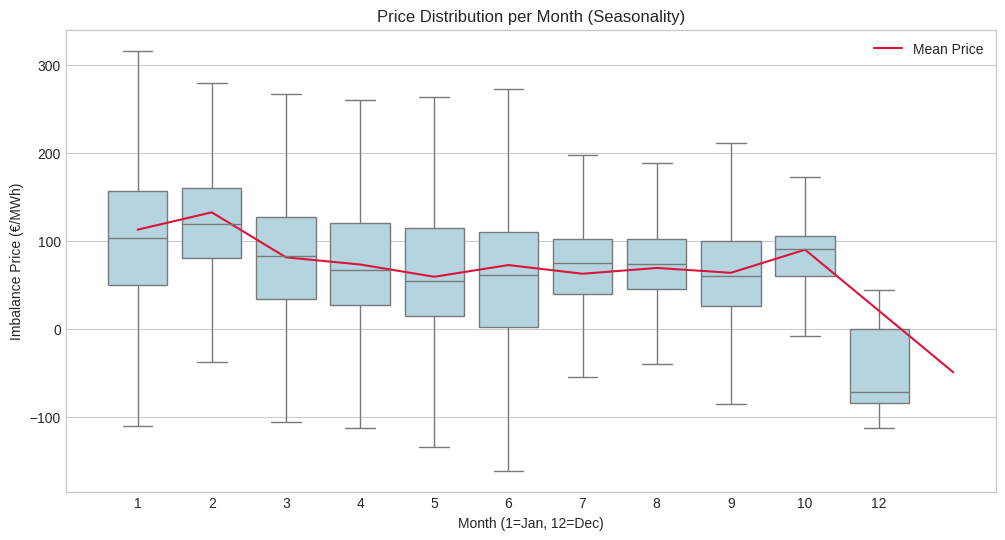

In [64]:
# Month and price
plt.figure(figsize=(12, 6))
# Using a boxplot shows the median + outliers per month
sns.boxplot(data=df, x='Month', y='Imbalance Price', showfliers=False, color='lightblue')
# Overlay the mean trend
sns.lineplot(data=df, x=df['Month']-1, y='Imbalance Price', color='crimson', label='Mean Price', errorbar=None)

plt.title("Price Distribution per Month (Seasonality)")
plt.ylabel("Imbalance Price (€/MWh)")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.legend()
plt.show()

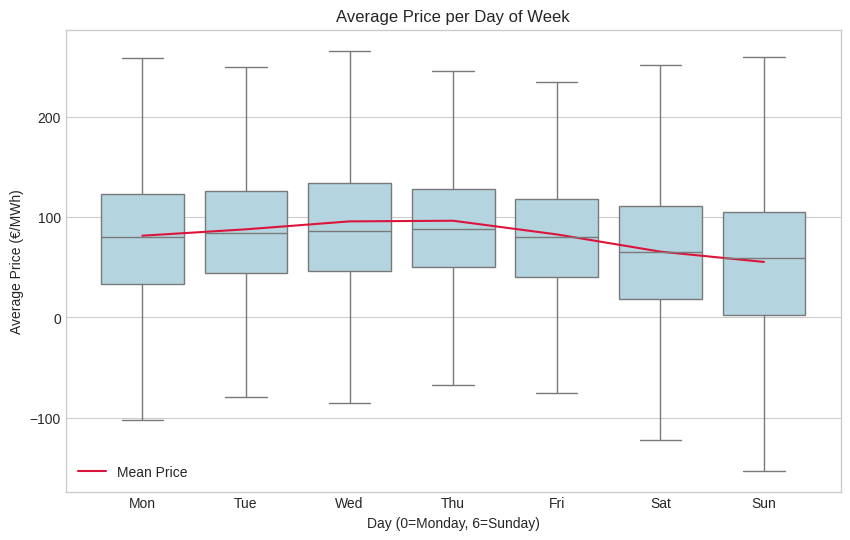

In [65]:
# Day
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='DayOfWeek', y='Imbalance Price', showfliers=False, color='lightblue')
sns.lineplot(data=df, x=df["DayOfWeek"], y='Imbalance Price', color='crimson', label='Mean Price', errorbar=None
             )
plt.title("Average Price per Day of Week")
plt.ylabel("Average Price (€/MWh)")
plt.xlabel("Day (0=Monday, 6=Sunday)")
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

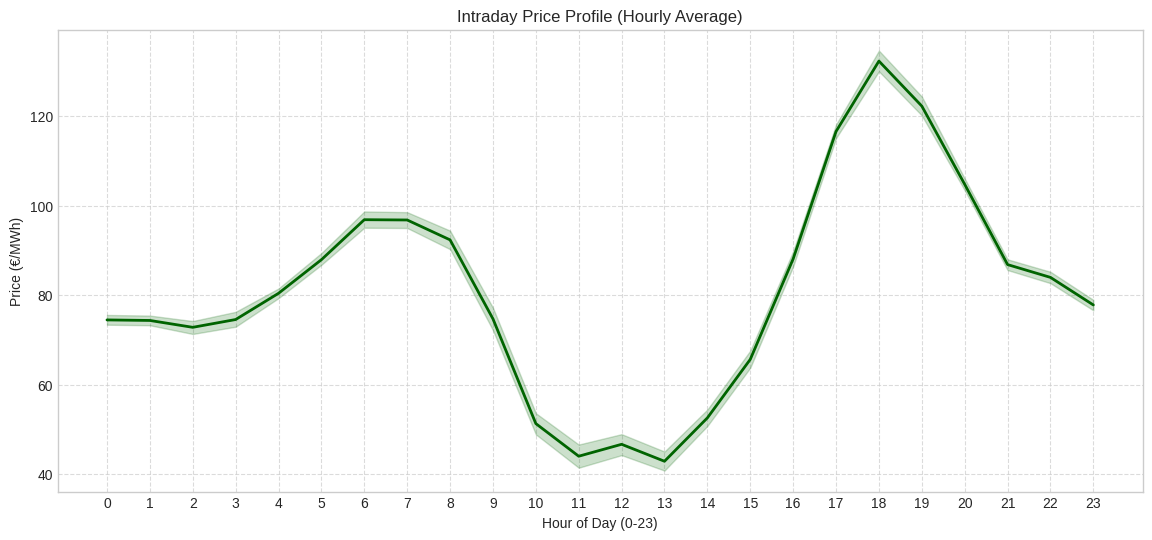

In [66]:
# Hour of the day
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Hour', y='Imbalance Price', color='darkgreen', linewidth=2)

plt.title("i Price Profile (Hourly Average)")
plt.ylabel("Price (€/MWh)")
plt.xlabel("Hour of Day (0-23)")
plt.xticks(range(0, 24))
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

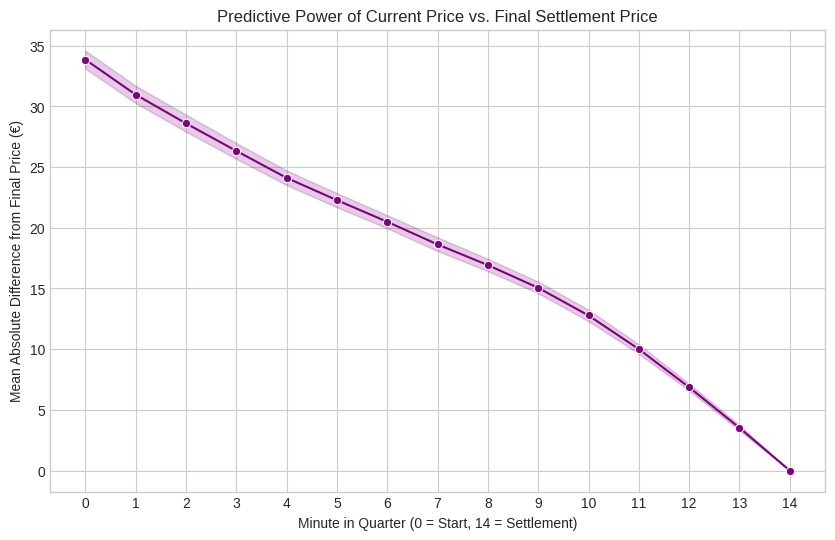

In [67]:
# Minute is a special case, here we want to look if each minute forecast has a higher chance of not being close to the final quarter price.

# Identify the "Final Price" for every quarter.
# We create a unique ID for each quarter to group them
df['Quarter_ID'] = (df['Datetime'].astype(int) // 10**9) // (15 * 60)

# Step B: Get the price at the last minute (min 14) of each quarter
quarter_finals = df[df['Minute_in_Quarter'] == 14][['Quarter_ID', 'Imbalance Price']]
quarter_finals = quarter_finals.rename(columns={'Imbalance Price': 'Final_Price'})

# Merge this final price back to the original dataframe
df_merged = pd.merge(df, quarter_finals, on='Quarter_ID', how='left')

# Calculate the Absolute Error (Difference between current price and final price)
df_merged['Price_Gap'] = (df_merged['Imbalance Price'] - df_merged['Final_Price']).abs()

# Plot average error per minute
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_merged, x='Minute_in_Quarter', y='Price_Gap', marker='o', color='purple')

plt.title("Predictive Power of Current Price vs. Final Settlement Price")
plt.ylabel("Mean Absolute Difference from Final Price (€)")
plt.xlabel("Minute in Quarter (0 = Start, 14 = Settlement)")
plt.xticks(range(0, 15))
plt.grid(True)
plt.show()

### Look at the correlation between uncertainty between minutes and the predictive ability of that minute.

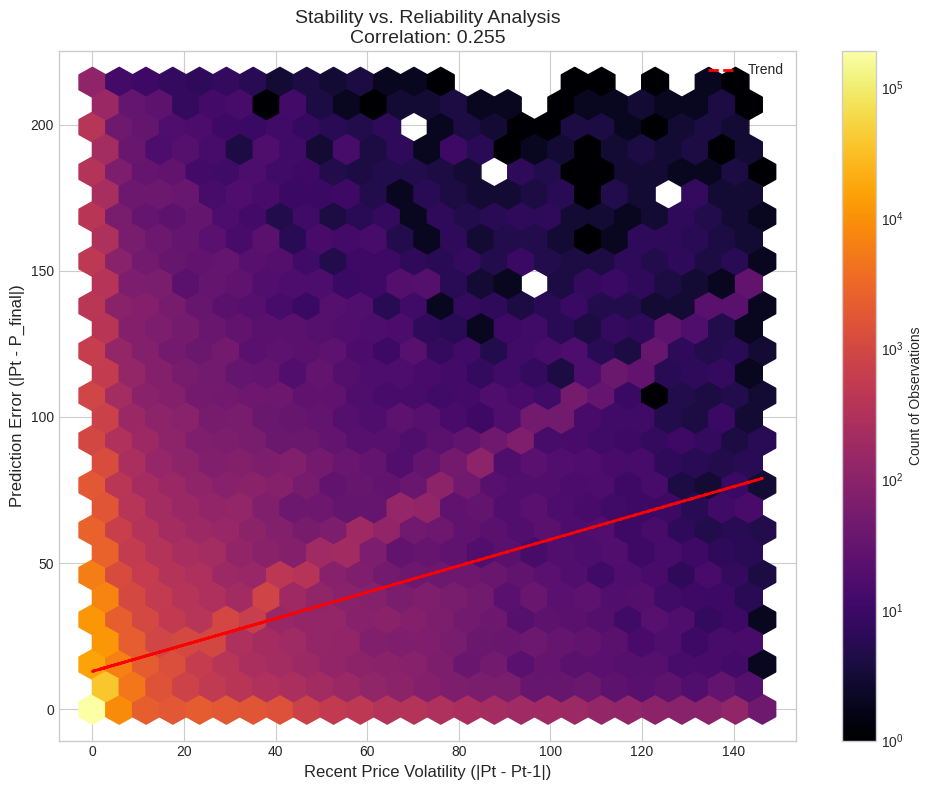

In [68]:
from scipy.stats import pearsonr
import numpy as np

# Create a unique ID for each quarter so we can match minutes to their specific end
df['Quarter_ID'] = (df['Datetime'].astype(int) // 10**9) // (15 * 60)
df['Minute_in_Quarter'] = df['Datetime'].dt.minute % 15

# 2. Calculate X-Axis: Recent Volatility (Delta)
# ------------------------------------------------------
# absolute difference between current price and previous price
df['Recent_Delta'] = df['Imbalance Price'].diff().abs()

# 3. Calculate Y-Axis: Final Error
# ------------------------------------------------------
# Get the price at minute 14 for every quarter
final_prices = df[df['Minute_in_Quarter'] == 14][['Quarter_ID', 'Imbalance Price']]
final_prices = final_prices.rename(columns={'Imbalance Price': 'Final_Price'})

# Merge this "truth" back onto the main dataframe
df_merged = pd.merge(df, final_prices, on='Quarter_ID', how='inner')

# Calculate how far the current price is from the final settlement
df_merged['Prediction_Error'] = (df_merged['Imbalance Price'] - df_merged['Final_Price']).abs()

# 4. Filter Data for Plotting
# ------------------------------------------------------
# We exclude Minute 14 (Error is always 0) and the very first row (Delta is NaN)
plot_data = df_merged[
    (df_merged['Minute_in_Quarter'] < 14) &
    (df_merged['Recent_Delta'].notna())
].copy()

# Optional: Remove extreme outliers for a cleaner plot (e.g., top 1%)
# This helps the visualization focus on the "normal" behavior
q99_delta = plot_data['Recent_Delta'].quantile(0.99)
q99_error = plot_data['Prediction_Error'].quantile(0.99)
plot_data = plot_data[
    (plot_data['Recent_Delta'] < q99_delta) &
    (plot_data['Prediction_Error'] < q99_error)
]

# 5. Visualization: Stability vs Reliability
# ------------------------------------------------------
plt.figure(figsize=(10, 8))

hb = plt.hexbin(
    x=plot_data['Recent_Delta'],
    y=plot_data['Prediction_Error'],
    gridsize=25,
    cmap='inferno',
    bins='log',
    mincnt=1
)

cb = plt.colorbar(hb, label='Count of Observations')

# Calculate and display the Correlation Coefficient
corr, _ = pearsonr(plot_data['Recent_Delta'], plot_data['Prediction_Error'])

plt.title(f"Stability vs. Reliability Analysis\nCorrelation: {corr:.3f}", fontsize=14)
plt.xlabel("Recent Price Volatility (|Pt - Pt-1|)", fontsize=12)
plt.ylabel("Prediction Error (|Pt - P_final|)", fontsize=12)

# Optional: Add a regression line to show the trend clearly
# We use numpy polyfit for a quick linear trend line
z = np.polyfit(plot_data['Recent_Delta'], plot_data['Prediction_Error'], 1)
p = np.poly1d(z)
plt.plot(plot_data['Recent_Delta'], p(plot_data['Recent_Delta']), "r--", linewidth=2, label='Trend')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_41996/1436120110.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


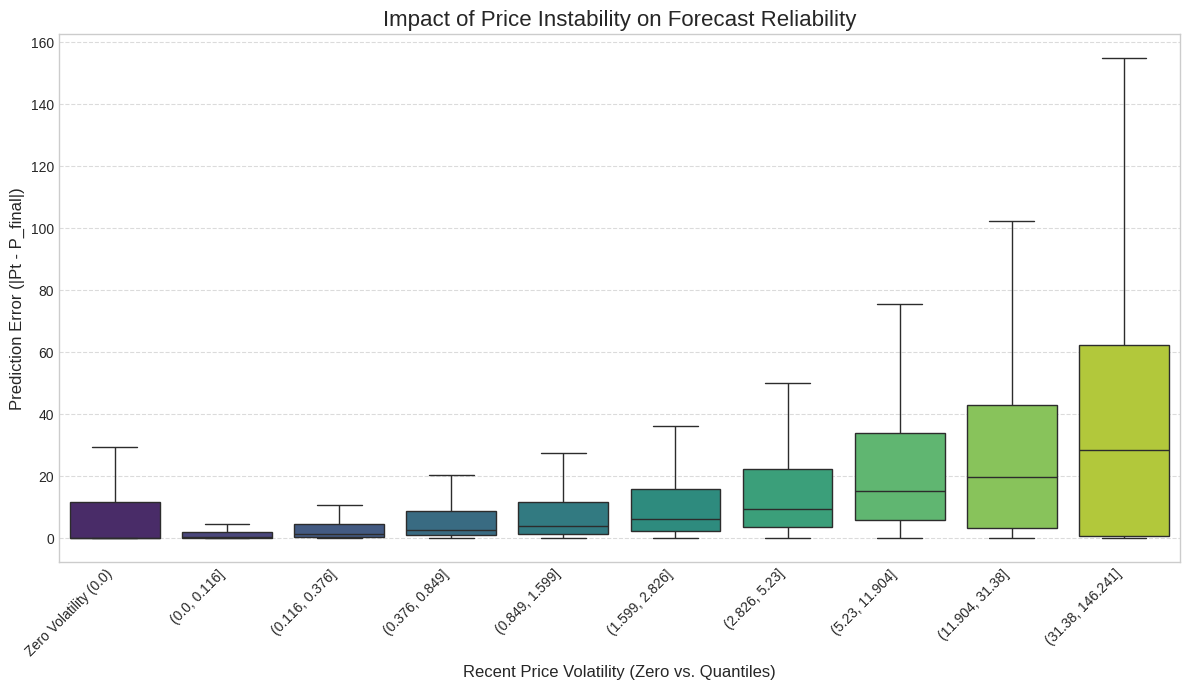

In [69]:
df['Recent_Delta'] = df['Imbalance Price'].diff().abs()

final_prices = df[df['Minute_in_Quarter'] == 14][['Quarter_ID', 'Imbalance Price']]
final_prices = final_prices.rename(columns={'Imbalance Price': 'Final_Price'})

df_merged = pd.merge(df, final_prices, on='Quarter_ID', how='inner')
df_merged['Prediction_Error'] = (df_merged['Imbalance Price'] - df_merged['Final_Price']).abs()

# Filter Data (Exclude min 14 and NaNs)
plot_data = df_merged[
    (df_merged['Minute_in_Quarter'] < 14) &
    (df_merged['Recent_Delta'].notna())
].copy()

# Remove extreme outliers (top 1%) to keep the plot readable
q99_delta = plot_data['Recent_Delta'].quantile(0.99)
plot_data = plot_data[plot_data['Recent_Delta'] < q99_delta]

zeros = plot_data[plot_data['Recent_Delta'] == 0].copy()
non_zeros = plot_data[plot_data['Recent_Delta'] > 0].copy()

# 2. Bin the Non-Zeros
# We create 9 bins for the data that actually moves.
# 'duplicates="drop"' handles edge cases where other values might repeat often.
non_zeros['Volatility_Bin'] = pd.qcut(non_zeros['Recent_Delta'], q=9, duplicates='drop')

# 3. Label the Zeros
# We create a dummy category for the zero-volatility data
zeros['Volatility_Bin'] = "Zero Volatility (0.0)"

# 4. Combine them back
plot_data_binned = pd.concat([zeros, non_zeros])

# 5. Sort the bins for the plot
# We need to make sure "Zero" comes first, followed by the intervals in order.
# Convert to string to ensure the 'Zero' label works with the interval objects.
plot_data_binned['Volatility_Bin'] = plot_data_binned['Volatility_Bin'].astype(str)
# Sort by the delta values to ensure the x-axis is ordered correctly
plot_data_binned = plot_data_binned.sort_values('Recent_Delta')

# ------------------------------------------------------
# Visualization
# ------------------------------------------------------
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=plot_data_binned,
    x='Volatility_Bin',
    y='Prediction_Error',
    palette='viridis', # 'viridis' usually looks better for ordered data than 'Blues'
    showfliers=False
)

plt.title("Impact of Price Instability on Forecast Reliability", fontsize=16)
plt.ylabel("Prediction Error (|Pt - P_final|)", fontsize=12)
plt.xlabel("Recent Price Volatility (Zero vs. Quantiles)", fontsize=12)

# Rotate labels and align them
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### The above gives a good view on the predictive ability. We see that if the predictive ability between the minutes is not good, the total prediction will also not be good.
### But this includes minutes that are close to the end final price. These influence the result positively. So a view on the most unpredictive minutes would also be interesting.

In [70]:
def analyze_minute_volatility(df_source, minute, ax_target, y_limit=None):
    """
    Analyzes volatility vs error for a specific minute and draws it on the given axis.
    """
    # Filter for the specific minute
    subset = df_source[df_source['Minute_in_Quarter'] == minute].copy()

    # Remove NaN (minute 0 of the whole dataset) and extreme outliers for clarity
    subset = subset.dropna(subset=['Recent_Delta'])
    subset = subset[subset['Recent_Delta'] < subset['Recent_Delta'].quantile(0.99)]

    # Split Zero vs Non-Zero
    zeros = subset[subset['Recent_Delta'] == 0].copy()
    non_zeros = subset[subset['Recent_Delta'] > 0].copy()

    # Create 5 bins for the non-zero data
    # We label them 1-5 so they look the same across different plots
    non_zeros['Bin_Label'] = pd.qcut(non_zeros['Recent_Delta'], q=5, labels=["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"])

    zeros['Bin_Label'] = "Zero (0.0)"
    # Combine
    plot_data = pd.concat([zeros, non_zeros])

    # Needed to enfore order
    order = ["Zero (0.0)", "Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]
    plot_data['Bin_Label'] = pd.Categorical(plot_data['Bin_Label'], categories=order, ordered=True)

    # Plot
    sns.boxplot(
        data=plot_data,
        x='Bin_Label',
        y='Prediction_Error',
        hue='Bin_Label',
        palette='viridis',
        showfliers=False,
        legend=False,
        ax=ax_target
    )

    ax_target.set_title(f"Minute {minute}", fontsize=14)
    ax_target.set_xlabel("Volatility Level")

    # Only show Y label on the first plot to save space
    if ax_target.get_subplotspec().is_first_col():
        ax_target.set_ylabel("Prediction Error (€)")
    else:
        ax_target.set_ylabel("")

    # Rotate x labels
    ax_target.tick_params(axis='x', rotation=45)
    ax_target.grid(True, axis='y', linestyle='--', alpha=0.5)

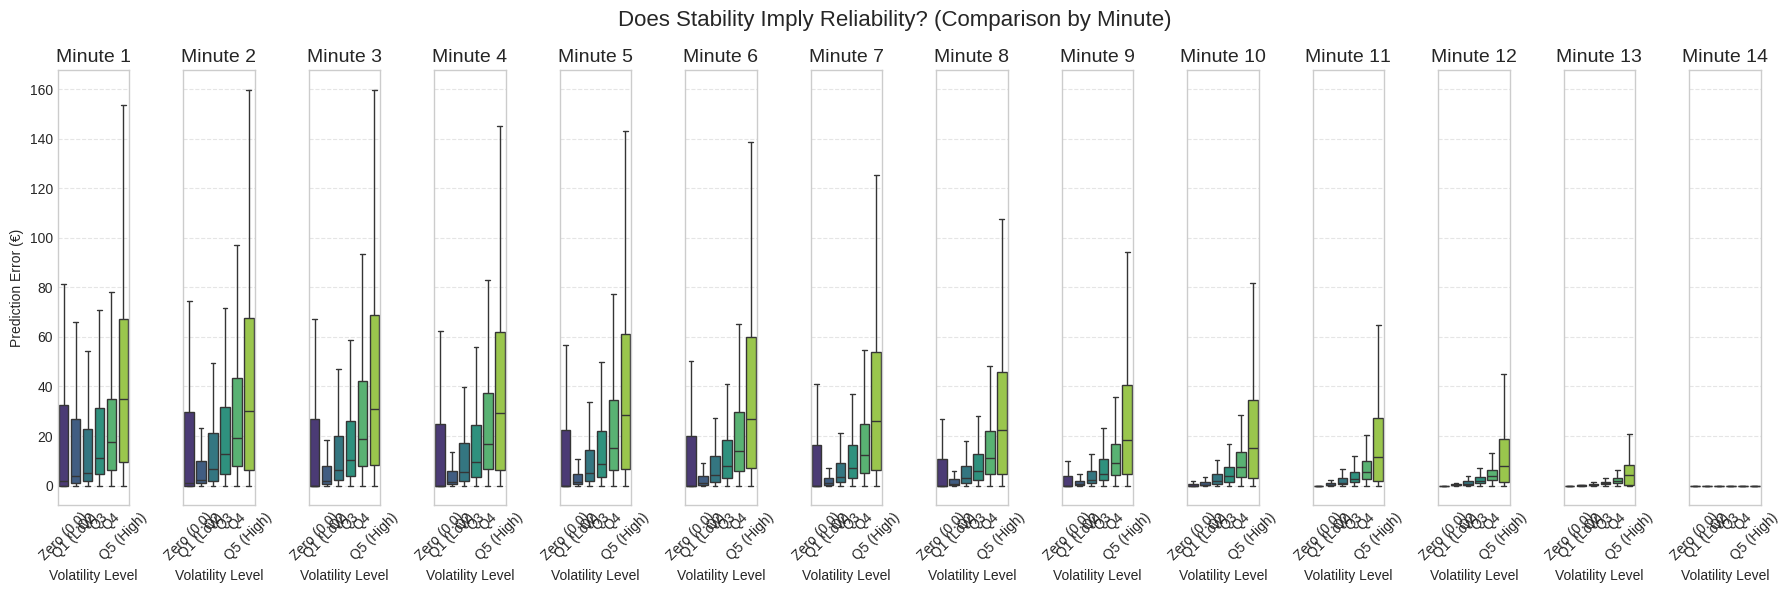

In [74]:
minutes_to_compare = [i for i in range(1, 15)]

# Create the subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(minutes_to_compare), figsize=(18, 6), sharey=True)

# Determine a common Y-axis limit for fairness
# We take the 95th percentile of errors to ignore extreme outliers in the scale
max_y = df_merged['Prediction_Error'].quantile(0.95)

for i, minute in enumerate(minutes_to_compare):
    analyze_minute_volatility(
        df_merged,
        minute=minute,
        ax_target=axes[i],
    )

plt.suptitle("Does Stability Imply Reliability? (Comparison by Minute)", fontsize=16)
plt.tight_layout()
plt.show()

### "Why is a zero difference more dangerous than a small one?"
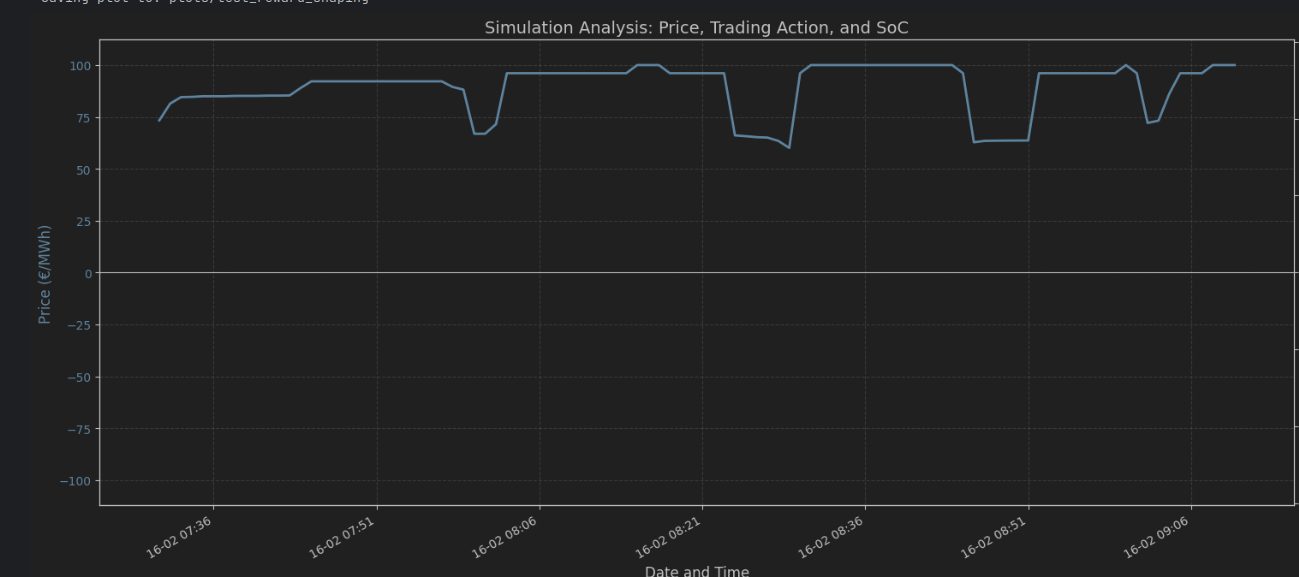
**Because of these plateaus** but why they are often wrong, a big question. Probably a lot of "people" see this as good, anticipate on it, but bring the network out of balance, and so Elia has to jump in.

/tmp/ipykernel_41996/2741790746.py:83: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_41996/2741790746.py:83: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/lander/Documents/school/Thesis/ThesisGit/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lander/Documents/school/Thesis/ThesisGit/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


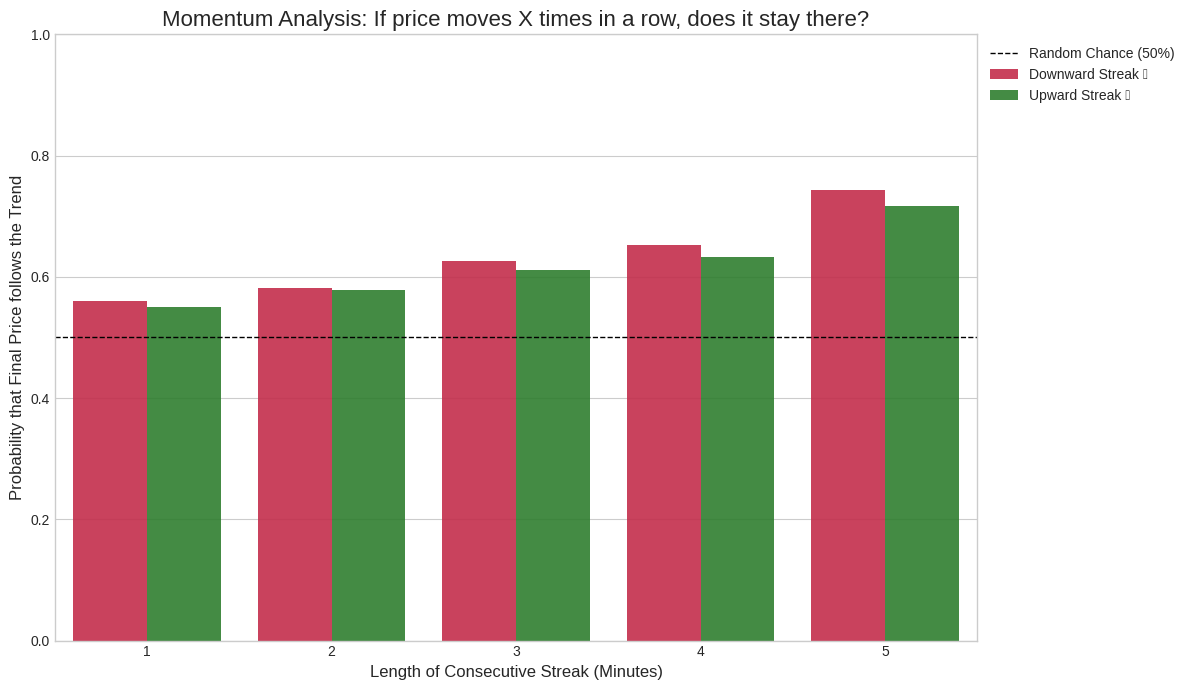

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


final_prices = df[df['Minute_in_Quarter'] == 14][['Quarter_ID', 'Imbalance Price']]
final_prices = final_prices.rename(columns={'Imbalance Price': 'Final_Price'})
df = pd.merge(df, final_prices, on='Quarter_ID', how='inner')
# Calculate price change from previous minute
df['Delta'] = df['Imbalance Price'].diff()

# Determine the direction (-1, 0, 1)
df['Direction'] = np.sign(df['Delta']).fillna(0)

# Identify where the direction changes or the quarter changes
# We check if (Direction != Prev_Direction) OR (Quarter != Prev_Quarter)
df['Group_Key'] = (
    (df['Direction'] != df['Direction'].shift()) |
    (df['Quarter_ID'] != df['Quarter_ID'].shift())
).cumsum()

# Count the cumulative size of each group
df['Streak_Count'] = df.groupby('Group_Key').cumcount() + 1

# Filter out Minute 0 (no streak possible) and Minute 14 (game over)
analysis_df = df[
    (df['Minute_in_Quarter'] > 0) &
    (df['Minute_in_Quarter'] < 14) &
    (df['Direction'] != 0) # Ignore flat movements for this specific trend analysis
].copy()

# 3. Determine the "Truth"
# ------------------------------------------------------
# Did the Final Price end up higher/lower than the Current Price?
# Truth = 1 if Final > Current, -1 if Final < Current
analysis_df['Future_Direction'] = np.sign(analysis_df['Final_Price'] - analysis_df['Imbalance Price'])

# 4. Success Check
# ------------------------------------------------------
# Does the current trend match the future outcome?
# If Streak is UP (1) and Future is UP (1) -> True
# If Streak is DOWN (-1) and Future is DOWN (-1) -> True
analysis_df['Trend_Continued'] = analysis_df['Direction'] == analysis_df['Future_Direction']

# 5. Aggregation for Plotting
# ------------------------------------------------------
# We group by (Direction, Streak_Count) and calculate the mean of 'Trend_Continued'
# This gives us the Probability (%) that the trend continued.

# Cap streaks at 5+ to keep the plot readable (streaks of 10 are rare and noisy)
analysis_df['Streak_Cap'] = analysis_df['Streak_Count'].clip(upper=5)

stats = analysis_df.groupby(['Direction', 'Streak_Cap'])['Trend_Continued'].mean().reset_index()

# Map labels for the plot
stats['Trend Type'] = stats['Direction'].map({1.0: 'Upward Streak 📈', -1.0: 'Downward Streak 📉'})

# ------------------------------------------------------
# Visualization
# ------------------------------------------------------
plt.figure(figsize=(12, 7))

# Draw the 50% line (Coin flip)
plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label="Random Chance (50%)")

# Bar Plot
sns.barplot(
    data=stats,
    x='Streak_Cap',
    y='Trend_Continued',
    hue='Trend Type',
    palette={'Upward Streak 📈': 'forestgreen', 'Downward Streak 📉': 'crimson'},
    alpha=0.9
)

plt.title("Momentum Analysis: If price moves X times in a row, does it stay there?", fontsize=16)
plt.ylabel("Probability that Final Price follows the Trend", fontsize=12)
plt.xlabel("Length of Consecutive Streak (Minutes)", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()